[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/RO/capitol16_notebook_curs.ipynb)

# Modelarea piețelor financiare — Capitolul 16: Active digitale și DeFi

*Notebook de curs. Daniel Traian Pele, Academia de Studii Economice din București.*

Acest notebook reproduce toate graficele și tabelele din Cursul 16: piața cripto, faptele stilizate, un indice de tip CRIX, stablecoin-urile, formatorii automați de piață, ETF-urile spot, acțiunile „cripto” și harta claselor de active.

In [1]:
import os
import json
import time
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.signal import lfilter
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

## Stil și funcții ajutătoare

In [2]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand (gri doar pentru linii de referinta si grila)
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Magenta  = '#D63384'
Brown    = '#795548'
Gray     = '#7F7F7F'
COL = {'BTC': Orange, 'ETH': Purple, 'XRP': MainBlue, 'ADA': Forest, 'DOGE': Amber, 'LTC': Teal, 'LINK': IDAred,
       'SOL': Magenta, 'BNB': Brown, 'SPX': MainBlue, 'GOLD': Amber, 'QQQ': Teal, 'USDT': Forest, 'USDC': MainBlue,
       'DAI': Orange, 'IBIT': MainBlue, 'ETHA': Purple, 'COIN': MainBlue, 'MSTR': IDAred, 'TLT': Forest}
CLASS_COL = {'Crypto': Orange, 'Equity': MainBlue, 'FX': Forest, 'Commodity': Amber, 'Bond': Purple}

HERE = '.'
SEED = 42
ETF_START = '2024-01-11'
B_BOOT = 2000


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=4, y=0.0):
    """O singura legenda sub o figura cu mai multe panouri."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    """Converteste recursiv numerele numpy si datele in tipuri JSON."""
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [jsonable(v) for v in x]
    if isinstance(x, (np.floating, float)):
        return None if not np.isfinite(x) else float(x)
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (pd.Timestamp,)):
        return str(x.date())
    return x


def max_drawdown(p):
    """Cea mai mare scadere de la un maxim anterior (in %) si data minimului."""
    dd = p / p.cummax() - 1
    return 100 * dd.min(), dd.idxmin()


def hill(x, frac=0.05):
    """Estimatorul Hill al indicelui de coada pentru cele mai mari frac din valorile pozitive ale lui x."""
    x = np.sort(x[x > 0])[::-1]
    k = max(int(frac * len(x)), 10)
    return 1 / np.mean(np.log(x[:k] / x[k]))


def hac_ols(y, X, lags=4):
    """Regresie OLS cu erori standard Newey-West (HAC)."""
    return sm.OLS(y, sm.add_constant(X)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})


import tempfile
HERE = tempfile.gettempdir()   # tabelele intermediare sunt scrise intr-un folder temporar


def save_fig(name):
    """Afiseaza figura."""
    plt.show()
    plt.close()

## Date

- Închideri zilnice până la 18 septembrie 2026: cripto-active 7 zile din 7; ETF-uri și acțiuni în zilele lucrătoare, ajustate pentru dividende și divizări.
- Monedele în circulație: Coin Metrics Community Data; valoarea totală blocată în DeFi și oferta de stablecoin-uri: DefiLlama.
- Analizele comune folosesc zilele comune: întâi îmbinăm prețurile, apoi calculăm randamentele.

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# cheie -> (simbol, eticheta, tip, id Coin Metrics)
ASSETS = {
    'BTC': ('BTC-USD.CC', 'Bitcoin', 'crypto', 'btc'),
    'ETH': ('ETH-USD.CC', 'Ethereum', 'crypto', 'eth'),
    'XRP': ('XRP-USD.CC', 'XRP', 'crypto', 'xrp'),
    'BNB': ('BNB-USD.CC', 'BNB', 'crypto', None),
    'SOL': ('SOL-USD.CC', 'Solana', 'crypto', None),
    'ADA': ('ADA-USD.CC', 'Cardano', 'crypto', 'ada'),
    'DOGE': ('DOGE-USD.CC', 'Dogecoin', 'crypto', 'doge'),
    'LTC': ('LTC-USD.CC', 'Litecoin', 'crypto', 'ltc'),
    'LINK': ('LINK-USD.CC', 'Chainlink', 'crypto', 'link'),
    'USDT': ('USDT-USD.CC', 'Tether (USDT)', 'crypto', None),
    'USDC': ('USDC-USD.CC', 'USD Coin (USDC)', 'crypto', None),
    'DAI': ('DAI-USD.CC', 'Dai', 'crypto', None),
    'IBIT': ('IBIT.US', 'IBIT (spot Bitcoin ETF)', 'etf', None),
    'ETHA': ('ETHA.US', 'ETHA (spot Ether ETF)', 'etf', None),
    'COIN': ('COIN.US', 'Coinbase', 'etf', None),
    'MSTR': ('MSTR.US', 'Strategy', 'etf', None),
    'QQQ': ('QQQ.US', 'Nasdaq 100 (QQQ)', 'etf', None),
    'GLD': ('GLD.US', 'Gold (GLD)', 'etf', None),
    'TLT': ('TLT.US', 'Long Treasuries (TLT)', 'etf', None),
    'SPX': ('GSPC.INDX', 'S&P 500', 'index', None),
    'GOLD': ('XAUUSD.FOREX', 'Gold (XAU/USD)', 'fx', None),
}
LABELS = {k: v[1] for k, v in ASSETS.items()}
# active cu pret in data/market si oferta curenta publica egala cu oferta in circulatie
# (XRP si Chainlink: oferta raportata include tokenurile detinute de emitent; Solana, BNB: fara oferta publica)
CRIX_UNIVERSE = ['BTC', 'ETH', 'DOGE', 'ADA', 'LTC']
STABLE = ['USDT', 'USDC', 'DAI']

_CACHE = {}
UA = {'User-Agent': 'Mozilla/5.0 (MFM course notebook)'}


def _get_json(url, tries=4):
    """Citeste un raspuns JSON."""
    for i in range(tries):
        try:
            return json.load(urllib.request.urlopen(urllib.request.Request(url, headers=UA), timeout=120))
        except Exception:
            if i == tries - 1:
                raise
            time.sleep(3 * (i + 1))


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    if symbol in _CACHE:
        return _CACHE[symbol]
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    _CACHE[symbol] = pd.read_csv(src, index_col='date', parse_dates=True).sort_index()
    return _CACHE[symbol]


def price(key, start=None, end=END, col=None):
    """Pretul zilnic curatat: cripto 7/7 (close), ETF/actiuni (adjusted_close), indici/FX (close) in zilele lucratoare."""
    symbol, _, kind, _ = ASSETS[key]
    d = read_market(symbol)
    col = col or ('adjusted_close' if kind == 'etf' else 'close')
    s = d[col].loc[start:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]
    if kind == 'index':
        s = s[s.diff() != 0]
    return s.rename(key)


def log_returns(key, start=None, end=END):
    """Randamente log pe calendarul propriu al seriei."""
    return np.log(price(key, start, end)).diff().dropna().rename(key)


def joint_prices(keys, start=None, end=END):
    """Preturi pentru mai multe active in zilele COMUNE (join pe preturi)."""
    return pd.concat([price(k, None, end) for k in keys], axis=1, join='inner').dropna().loc[start:]


def joint_returns(keys, start=None, end=END, freq=None):
    """Randamente log comune: join pe preturi, optional esantionare saptamanala (vineri), apoi randamente."""
    p = joint_prices(keys, None, end)
    if freq == 'W':
        p = p.resample('W-FRI').last().dropna()
    return np.log(p).diff().dropna().loc[start:]


def periods_per_year(r):
    """Frecventa reala: numarul mediu de observatii pe an calendaristic."""
    return len(r) / ((r.index[-1] - r.index[0]).days / 365.25)


def coin_supply(asset, start='2017-01-01', end=END):
    """Oferta curenta (SplyCur) zilnica a unui cripto-activ, din Coin Metrics Community Data."""
    key = ('supply', asset, start, end)
    if key in _CACHE:
        return _CACHE[key]
    url = ('https://community-api.coinmetrics.io/v4/timeseries/asset-metrics?assets=' + asset +
           f'&metrics=SplyCur&frequency=1d&start_time={start}&end_time={end}&page_size=10000')
    rows = []
    while url:
        js = _get_json(url)
        rows += js.get('data', [])
        url = js.get('next_page_url')
    s = pd.Series({pd.Timestamp(r['time'][:10]): float(r['SplyCur']) for r in rows}).sort_index()
    _CACHE[key] = s.rename(asset)
    return _CACHE[key]


def market_values(keys=CRIX_UNIVERSE, start='2018-01-01', end=END):
    """Valoarea de piata zilnica = pretul de inchidere x oferta curenta, in miliarde USD."""
    out = {}
    for k in keys:
        p = price(k, start, end)
        s = coin_supply(ASSETS[k][3], start, end).reindex(p.index).ffill()
        out[k] = p * s / 1e9
    return pd.DataFrame(out).dropna()


def defi_tvl():
    """Valoarea totala blocata (TVL) in protocoalele DeFi, toate blockchain-urile, miliarde USD (DefiLlama)."""
    if 'tvl' not in _CACHE:
        js = _get_json('https://api.llama.fi/v2/historicalChainTvl')
        s = pd.Series({pd.Timestamp(int(x['date']), unit='s').normalize(): x['tvl'] / 1e9 for x in js}).sort_index()
        _CACHE['tvl'] = s[s > 0].loc[:END].rename('TVL')
    return _CACHE['tvl']


def stablecoin_chart(sid=None):
    """Oferta in circulatie (miliarde unitati) si valoarea ei (miliarde USD); sid=None: toate stablecoin-urile in USD."""
    key = ('stable', sid)
    if key not in _CACHE:
        url = 'https://stablecoins.llama.fi/stablecoincharts/all' + (f'?stablecoin={sid}' if sid else '')
        js = _get_json(url)
        rows = {}
        for x in js:
            d = pd.Timestamp(int(x['date']), unit='s').normalize()
            c = (x.get('totalCirculating') or {}).get('peggedUSD')
            v = (x.get('totalCirculatingUSD') or {}).get('peggedUSD')
            if c is not None:
                rows[d] = (c / 1e9, (v if v is not None else np.nan) / 1e9)
        df = pd.DataFrame(rows, index=['supply', 'value']).T.sort_index()
        _CACHE[key] = df.loc[:END]
    return _CACHE[key]


def stablecoin_list():
    """Stablecoin-urile ancorate la USD de azi: simbol, nume, mecanism de ancorare, oferta (miliarde USD)."""
    if 'slist' not in _CACHE:
        js = _get_json('https://stablecoins.llama.fi/stablecoins?includePrices=false')['peggedAssets']
        rows = [dict(id=x['id'], symbol=x['symbol'], name=x['name'], mechanism=x.get('pegMechanism'),
                     supply=((x.get('circulating') or {}).get('peggedUSD') or 0) / 1e9)
                for x in js if x.get('pegType') == 'peggedUSD']
        _CACHE['slist'] = pd.DataFrame(rows).sort_values('supply', ascending=False).reset_index(drop=True)
    return _CACHE['slist']


def chain_tvl():
    """TVL de azi pe blockchain-uri, miliarde USD (DefiLlama)."""
    if 'chains' not in _CACHE:
        js = _get_json('https://api.llama.fi/v2/chains')
        s = pd.Series({x['name']: (x.get('tvl') or 0) / 1e9 for x in js}).sort_values(ascending=False)
        _CACHE['chains'] = s
    return _CACHE['chains']


# universul pentru clasificarea activelor (in spiritul Pele et al., 2023): simbol -> (eticheta, clasa, tip)
CLASS_ASSETS = {
    'BTC-USD.CC': ('Bitcoin', 'Crypto', 'crypto'), 'ETH-USD.CC': ('Ethereum', 'Crypto', 'crypto'),
    'XRP-USD.CC': ('XRP', 'Crypto', 'crypto'), 'LTC-USD.CC': ('Litecoin', 'Crypto', 'crypto'),
    'DOGE-USD.CC': ('Dogecoin', 'Crypto', 'crypto'), 'ADA-USD.CC': ('Cardano', 'Crypto', 'crypto'),
    'LINK-USD.CC': ('Chainlink', 'Crypto', 'crypto'), 'BNB-USD.CC': ('BNB', 'Crypto', 'crypto'),
    'GSPC.INDX': ('S&P 500', 'Equity', 'index'), 'NDX.INDX': ('Nasdaq 100', 'Equity', 'index'),
    'STOXX50E.INDX': ('Euro Stoxx 50', 'Equity', 'index'), 'GDAXI.INDX': ('DAX', 'Equity', 'index'),
    'N225.INDX': ('Nikkei 225', 'Equity', 'index'), 'BET': ('BET', 'Equity', 'index'),
    'EURUSD.FOREX': ('EUR/USD', 'FX', 'fx'), 'USDJPY.FOREX': ('USD/JPY', 'FX', 'fx'),
    'GBPUSD.FOREX': ('GBP/USD', 'FX', 'fx'), 'USDCHF.FOREX': ('USD/CHF', 'FX', 'fx'),
    'XAUUSD.FOREX': ('Gold', 'Commodity', 'fx'), 'USO.US': ('Oil (USO)', 'Commodity', 'etf'),
    'UNG.US': ('Natural gas (UNG)', 'Commodity', 'etf'), 'DBC.US': ('Commodities (DBC)', 'Commodity', 'etf'),
    'TLT.US': ('Long Treasuries (TLT)', 'Bond', 'etf'), 'IEF.US': ('7-10y Treasuries (IEF)', 'Bond', 'etf'),
    'LQD.US': ('Corporate IG (LQD)', 'Bond', 'etf'), 'HYG.US': ('High yield (HYG)', 'Bond', 'etf'),
}


def symbol_returns(symbol, start=None, end=END):
    """Randamente log zilnice pentru un simbol din CLASS_ASSETS, pe calendarul propriu."""
    _, _, kind = CLASS_ASSETS[symbol]
    d = read_market(symbol)
    s = d['adjusted_close' if kind == 'etf' else 'close'].loc[:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]
    if kind == 'index':
        s = s[s.diff() != 0]
    return np.log(s).diff().dropna().loc[start:end]

## 1. Valoarea de piață și concentrarea

- Valoarea de piață $M = P \times Q$ (prețul înmulțit cu monedele în circulație); ponderea Bitcoin; $\mathrm{HHI} = \sum_i w_i^2$.

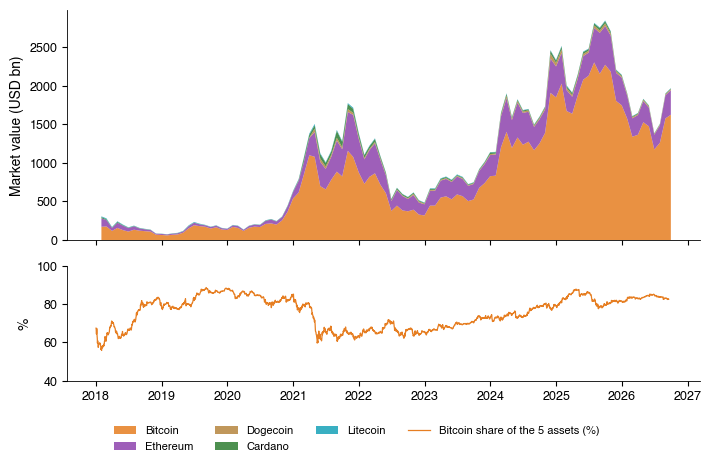

{'start': '2018-01-01',
 'total_end': np.float64(1970.1983113131482),
 'total_peak': 3135.03803985598,
 'total_peak_date': '2025-10-06',
 'btc_share_end': np.float64(82.47931391018477),
 'btc_share_min': 55.77432147709041,
 'btc_share_min_date': '2018-02-01',
 'btc_share_max': 88.52103488826371,
 'btc_share_max_date': '2019-09-05',
 'eth_share_end': np.float64(16.17761661243015),
 'hhi_end': np.float64(0.7065262133557164),
 'neff_end': np.float64(1.4153756521649787),
 'mv_end': {'BTC': np.float64(1625.006049841131),
  'ETH': np.float64(318.73112930881416),
  'DOGE': np.float64(13.633802583006075),
  'ADA': np.float64(8.32487624237569),
  'LTC': np.float64(4.502453337821162)},
 'btc_price_end': np.float64(80901.4609375),
 'btc_supply_end': np.float64(20086238.6291951),
 'eth_price_end': np.float64(2611.3471679688),
 'eth_supply_end': np.float64(122056206.55055785),
 'end': '2026-09-18'}

In [4]:
def fig_market_value():
    """Valoarea de piata (pret x oferta curenta) a activelor din universul indicelui, 2018-2026."""
    mv = market_values()
    m = mv.resample('ME').last()
    tot = mv.sum(axis=1)
    share = 100 * mv['BTC'] / tot
    fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.2), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    axes[0].stackplot(m.index, [m[k] for k in CRIX_UNIVERSE], labels=[LABELS[k] for k in CRIX_UNIVERSE],
                      colors=[COL[k] for k in CRIX_UNIVERSE], alpha=0.85, lw=0)
    axes[0].set_ylabel('Market value (USD bn)')
    axes[1].plot(share.index, share.values, color=Orange, lw=0.9, label=f'Bitcoin share of the {len(CRIX_UNIVERSE)} assets (%)')
    axes[1].set_ylabel('%')
    axes[1].set_ylim(40, 100)
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=4, y=0.0)
    save_fig('ch16_market_value')
    hhi = ((mv.div(tot, axis=0)) ** 2).sum(axis=1)
    return dict(start=str(mv.index[0].date()), total_end=tot.iloc[-1], total_peak=tot.max(),
                total_peak_date=str(tot.idxmax().date()), btc_share_end=share.iloc[-1], btc_share_min=share.min(),
                btc_share_min_date=str(share.idxmin().date()), btc_share_max=share.max(),
                btc_share_max_date=str(share.idxmax().date()), eth_share_end=100 * mv['ETH'].iloc[-1] / tot.iloc[-1],
                hhi_end=hhi.iloc[-1], neff_end=1 / hhi.iloc[-1], mv_end={k: mv[k].iloc[-1] for k in CRIX_UNIVERSE},
                btc_price_end=price('BTC').iloc[-1], btc_supply_end=1e9 * mv['BTC'].iloc[-1] / price('BTC').iloc[-1],
                eth_price_end=price('ETH').iloc[-1], eth_supply_end=1e9 * mv['ETH'].iloc[-1] / price('ETH').iloc[-1],
                end=str(mv.index[-1].date()))


fig_market_value()

## 2. Faptele stilizate: cripto vs acțiuni și aur

In [5]:
STYL = ['BTC', 'ETH', 'SOL', 'DOGE', 'SPX', 'GOLD']


def stylised_table(start='2018-01-01'):
    """Momente, cozi, autocorelatii, scaderi maxime si VaR 1% / ES 2.5% istorice, fiecare serie pe calendarul ei."""
    rows = {}
    for k in STYL:
        p = price(k, start)
        r = 100 * np.log(p).diff().dropna()
        ppy = periods_per_year(r)
        q = np.quantile(r, 0.01)
        q25 = np.quantile(r, 0.025)
        mdd, mdd_date = max_drawdown(p)
        rows[k] = dict(N=len(r), start=str(r.index[0].date()), ppy=ppy, ann_mean=r.mean() * ppy,
                       ann_vol=r.std() * np.sqrt(ppy), skew=stats.skew(r), kurt=stats.kurtosis(r),
                       acf1=r.autocorr(1), acf1_abs=r.abs().autocorr(1), var1=-q, es2_5=-r[r <= q25].mean(),
                       min=r.min(), min_date=str(r.idxmin().date()), mdd=mdd, mdd_date=str(mdd_date.date()),
                       hill_left=hill(-r.values), share5sd=100 * (np.abs(r - r.mean()) > 5 * r.std()).mean())
    t = pd.DataFrame(rows).T
    t.to_csv(os.path.join(HERE, 'ch16_stylised_facts.csv'))
    return t


t = stylised_table()
t

,N,start,ppy,ann_mean,ann_vol,skew,kurt,acf1,acf1_abs,var1,es2_5,min,min_date,mdd,mdd_date,hill_left,share5sd
BTC,3182,2018-01-02,365.364822,20.4265,64.121262,-0.945702,14.833063,-0.046503,0.167694,10.223854,10.287778,-46.473021,2020-03-12,-81.532712,2018-12-15,2.72793,0.157134
ETH,3182,2018-01-02,365.364822,13.98315,84.337038,-0.824251,11.060023,-0.046054,0.155464,13.488352,13.684192,-55.073172,2020-03-12,-93.96254,2018-12-14,2.668015,0.125707
SOL,2351,2020-04-12,365.405426,77.345701,117.063048,-0.218955,7.88839,-0.041977,0.276674,14.46206,17.144676,-54.958202,2022-11-09,-96.272497,2022-12-29,2.848669,0.255211
DOGE,3182,2018-01-02,365.364822,26.220821,123.921147,4.876032,106.366343,0.027021,0.370681,13.791233,16.350159,-51.511165,2021-01-30,-92.258478,2022-06-18,2.832624,0.408548
SPX,2189,2018-01-03,251.425236,11.98057,19.187759,-0.645527,14.922445,-0.144612,0.357301,3.429764,3.83186,-12.765218,2020-03-16,-33.92496,2020-03-23,2.869843,0.411147
GOLD,2269,2018-01-02,260.531987,13.88689,17.205721,-0.548312,10.255483,-0.021102,0.125691,2.998658,3.181783,-11.140951,2026-01-30,-27.700612,2026-07-16,2.746899,0.264434


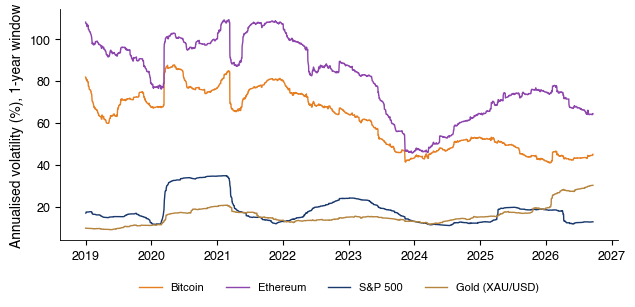

{'BTC': {'last': np.float64(45.08038507447969), 'min': 41.05212934873849, 'max': 87.77537444424225, 'min_date': '2026-01-19'}, 'ETH': {'last': np.float64(64.49569028563712), 'min': 45.7117162746907, 'max': 109.32164328592238, 'min_date': '2023-12-20'}, 'SPX': {'last': np.float64(12.902675341021537), 'min': 11.10037329316607, 'max': 34.910212692846976, 'min_date': '2024-07-09'}, 'GOLD': {'last': np.float64(30.31229786348122), 'min': 9.120586866740108, 'max': 30.31229786348122, 'min_date': '2019-05-15'}, 'btc_eth_ratio_last': np.float64(1.430681884794914), 'btc_spx_ratio_last': np.float64(3.4938788958872284)}


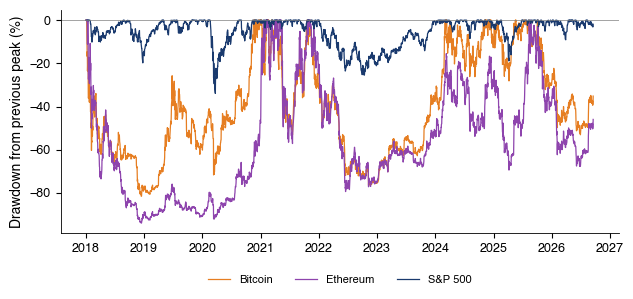

{'BTC': {'min': -81.5327115591944,
  'min_date': '2018-12-15',
  'last': np.float64(-35.15044383776625),
  'share_below50': np.float64(36.380772855796415)},
 'ETH': {'min': -93.96254040497699,
  'min_date': '2018-12-14',
  'last': np.float64(-45.94993411408358),
  'share_below50': np.float64(61.262959472196044)},
 'SPX': {'min': -33.9249600261347,
  'min_date': '2020-03-23',
  'last': np.float64(-1.903963229904937),
  'share_below50': np.float64(0.0)}}

In [6]:
def fig_rolling_vol(start='2018-01-01'):
    """Volatilitatea anualizata pe ferestre mobile de un an calendaristic."""
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    out = {}
    for k in ['BTC', 'ETH', 'SPX', 'GOLD']:
        r = log_returns(k, start)
        ppy = periods_per_year(r)
        v = 100 * r.rolling('365D', min_periods=int(0.9 * ppy)).std() * np.sqrt(ppy)
        v = v.loc['2019-01-01':]
        ax.plot(v.index, v.values, color=COL[k], lw=1.0, label=LABELS[k])
        out[k] = dict(last=v.iloc[-1], min=v.min(), max=v.max(), min_date=str(v.idxmin().date()))
    ax.set_ylabel('Annualised volatility (%), 1-year window')
    legend_outside_bottom(ax, ncol=4, y=-0.14)
    save_fig('ch16_rolling_vol')
    out['btc_eth_ratio_last'] = out['ETH']['last'] / out['BTC']['last']
    out['btc_spx_ratio_last'] = out['BTC']['last'] / out['SPX']['last']
    return out


def fig_drawdowns(start='2018-01-01'):
    """Scaderea de la maximul anterior pentru Bitcoin, Ethereum si S&P 500."""
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    out = {}
    for k in ['BTC', 'ETH', 'SPX']:
        p = price(k, start)
        dd = 100 * (p / p.cummax() - 1)
        ax.plot(dd.index, dd.values, color=COL[k], lw=0.9, label=LABELS[k])
        out[k] = dict(min=dd.min(), min_date=str(dd.idxmin().date()), last=dd.iloc[-1],
                      share_below50=100 * (dd < -50).mean())
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_ylabel('Drawdown from previous peak (%)')
    legend_outside_bottom(ax, ncol=3, y=-0.14)
    save_fig('ch16_drawdowns')
    return out


print(fig_rolling_vol())
fig_drawdowns()

## 3. Ziua săptămânii și corelațiile

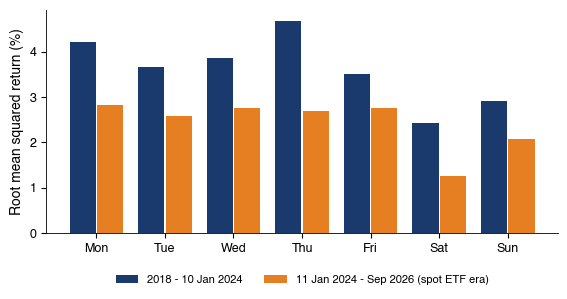

{'ratio_pre': np.float64(0.4489149530352716),
 'ratio_post': np.float64(0.39371310353710176),
 'pre': [4.210785207384411,
  3.6645981136683408,
  3.8645614356818263,
  4.6812465505682015,
  3.5051702619422036,
  2.4299493686905316,
  2.917442894048991],
 'post': [2.815342740128887,
  2.5876346352361748,
  2.765335071826396,
  2.692097883386533,
  2.7671254737252875,
  1.2599252326064567,
  2.0656473590581763],
 'wd_pre': np.float64(4.007073104772058),
 'we_pre': np.float64(2.684783694679747),
 'wd_post': np.float64(2.726672309948462),
 'we_post': np.float64(1.7108931298801882)}

In [7]:
def fig_weekday(start='2018-01-01'):
    """Dispersia randamentelor Bitcoin pe zile ale saptamanii, inainte si dupa lansarea ETF-urilor spot."""
    r = 100 * log_returns('BTC', start)
    pre, post = r.loc[:'2024-01-10'], r.loc[ETF_START:]
    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    v_pre = pre.groupby(pre.index.dayofweek).apply(lambda x: np.sqrt((x ** 2).mean()))
    v_post = post.groupby(post.index.dayofweek).apply(lambda x: np.sqrt((x ** 2).mean()))
    fig, ax = plt.subplots(figsize=(6.6, 2.9))
    x = np.arange(7)
    ax.bar(x - 0.2, v_pre.values, 0.38, color=MainBlue, label='2018 - 10 Jan 2024')
    ax.bar(x + 0.2, v_post.values, 0.38, color=Orange, label='11 Jan 2024 - Sep 2026 (spot ETF era)')
    ax.set_xticks(x)
    ax.set_xticklabels(days)
    ax.set_ylabel('Root mean squared return (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_weekday')

    def ratio(x):
        we = x[x.index.dayofweek >= 5]
        wd = x[x.index.dayofweek < 5]
        return (we ** 2).mean() / (wd ** 2).mean()
    return dict(ratio_pre=ratio(pre), ratio_post=ratio(post), pre=v_pre.tolist(), post=v_post.tolist(),
                wd_pre=np.sqrt((pre[pre.index.dayofweek < 5] ** 2).mean()),
                we_pre=np.sqrt((pre[pre.index.dayofweek >= 5] ** 2).mean()),
                wd_post=np.sqrt((post[post.index.dayofweek < 5] ** 2).mean()),
                we_post=np.sqrt((post[post.index.dayofweek >= 5] ** 2).mean()))


fig_weekday()

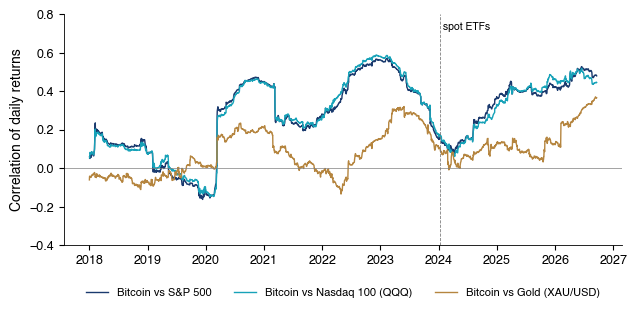

{'SPX': {'p1': np.float64(0.022891398561799288),
  'p1_n': 753,
  'p2': np.float64(0.3915765252495031),
  'p2_n': 1006,
  'p3': np.float64(0.383856462209531),
  'p3_n': 674,
  'last': np.float64(0.4798528983979601),
  'max': 0.5705525534112205,
  'max_date': '2023-02-09'},
 'QQQ': {'p1': np.float64(0.026585074790159677),
  'p1_n': 754,
  'p2': np.float64(0.40180442680585915),
  'p2_n': 1006,
  'p3': np.float64(0.3788257054777565),
  'p3_n': 674,
  'last': np.float64(0.4454113497509316),
  'max': 0.5878568777315023,
  'max_date': '2022-12-05'},
 'GOLD': {'p1': np.float64(-0.019865700964636634),
  'p1_n': 780,
  'p2': np.float64(0.12216042926899155),
  'p2_n': 1042,
  'p3': np.float64(0.21797159211189007),
  'p3_n': 700,
  'last': np.float64(0.3658180592083669),
  'max': 0.3705709745685086,
  'max_date': '2026-09-11'}}

In [8]:
def fig_rolling_corr():
    """Corelatia pe 250 de zile comune: Bitcoin cu S&P 500, Nasdaq 100 si aurul (join pe preturi)."""
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    out = {}
    for k, c in [('SPX', MainBlue), ('QQQ', Teal), ('GOLD', Amber)]:
        r = joint_returns(['BTC', k], '2016-01-01')
        rc = r['BTC'].rolling(250).corr(r[k]).loc['2018-01-01':]
        ax.plot(rc.index, rc.values, color=c, lw=1.0, label=f'Bitcoin vs {LABELS[k]}')
        per = {}
        for lab, a, b in [('p1', '2017-01-01', '2019-12-31'), ('p2', '2020-01-01', '2023-12-31'),
                          ('p3', ETF_START, END)]:
            x = r.loc[a:b]
            per[lab] = x['BTC'].corr(x[k])
            per[lab + '_n'] = len(x)
        out[k] = dict(per, last=rc.iloc[-1], max=rc.max(), max_date=str(rc.idxmax().date()))
    ax.axhline(0, color=Gray, lw=0.5)
    ax.axvline(pd.Timestamp(ETF_START), color=Gray, lw=0.6, ls='--')
    ax.text(pd.Timestamp(ETF_START), 0.72, ' spot ETFs', fontsize=7.5, color='black')
    ax.set_ylabel('Correlation of daily returns')
    ax.set_ylim(-0.4, 0.8)
    legend_outside_bottom(ax, ncol=3, y=-0.14)
    save_fig('ch16_rolling_corr')
    return out


fig_rolling_corr()

## 4. Un indice de tip CRIX

- Indice Laspeyres cu realocare lunară și divizor; indici cu primele $k$ monede; $\mathrm{AIC}(k) = n\ln\hat\sigma_k^2 + 2k$.

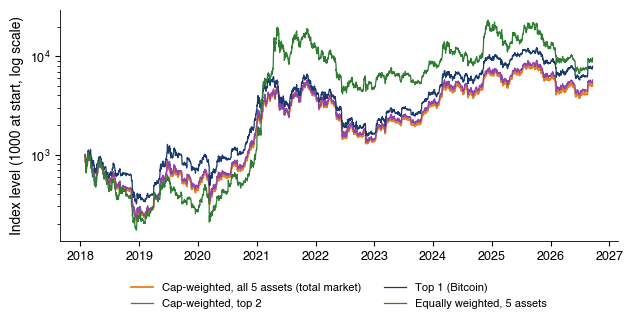

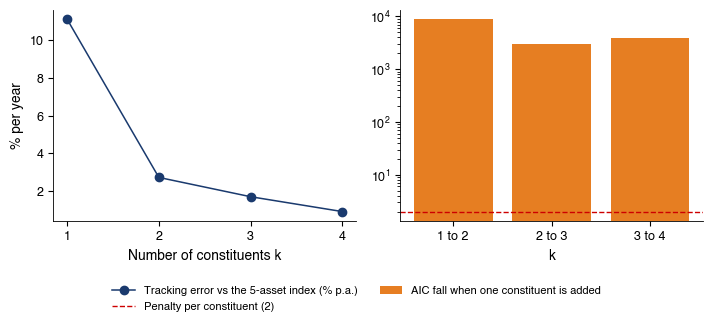

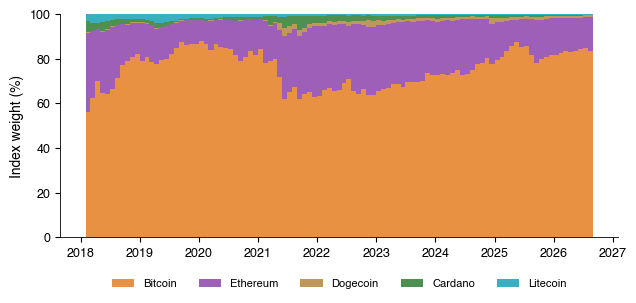

{'aic': {'1': np.float64(-32436.59706166621),
  '2': np.float64(-41329.45147225557),
  '3': np.float64(-44320.548795933835),
  '4': np.float64(-48299.388597705314)},
 'te': {'1': np.float64(11.126457577950458),
  '2': np.float64(2.7139930556502425),
  '3': np.float64(1.6883241992412648),
  '4': np.float64(0.8978427438082407)},
 'k_aic': 4,
 'tot_cagr': np.float64(21.36104937450185),
 'ew_cagr': np.float64(30.016913072188032),
 'tot_vol': np.float64(65.72233698067389),
 'ew_vol': np.float64(82.45887604634147)}

In [9]:
def crix_index(k=None, weighting='cap', mv=None, px=None):
    """Indice Laspeyres cu reponderare lunara: primii k constituenti dupa valoarea de piata la sfarsitul lunii
    anterioare; cantitatile sunt fixe in cursul lunii, iar divizorul pastreaza continuitatea la reponderare."""
    if mv is None:
        mv = market_values()
    if px is None:
        px = pd.concat([price(a) for a in CRIX_UNIVERSE], axis=1).reindex(mv.index)
    months = mv.index.to_period('M')
    level = pd.Series(np.nan, index=mv.index)
    wts = {}
    val = 1000.0
    first = True
    for per in months.unique():
        idx = mv.index[months == per]
        prev = mv.loc[:idx[0] - pd.Timedelta(days=1)]
        if prev.empty:
            continue
        base = prev.iloc[-1]
        members = base.sort_values(ascending=False).index[:(k or len(base))]
        w = base[members] / base[members].sum() if weighting == 'cap' else pd.Series(1 / len(members), index=members)
        p0 = px.loc[prev.index[-1], members]
        rel = (px.loc[idx, members] / p0).mul(w, axis=1).sum(axis=1)
        if first:
            level.loc[prev.index[-1]] = val
            first = False
        level.loc[idx] = val * rel
        val = level.loc[idx[-1]]
        wts[str(per)] = w.reindex(CRIX_UNIVERSE).fillna(0)
    return level.dropna(), pd.DataFrame(wts).T


def crix_aic(mv=None, px=None):
    """AIC(k) = n ln(s2_k) + 2k, cu s2_k media patratelor diferentelor dintre randamentele log ale indicelui total
    (toti cei 7 constituenti) si ale indicelui cu k constituenti; pe intreaga perioada si pe fiecare an."""
    if mv is None:
        mv = market_values()
    if px is None:
        px = pd.concat([price(a) for a in CRIX_UNIVERSE], axis=1).reindex(mv.index)
    tot, _ = crix_index(None, 'cap', mv, px)
    rt = np.log(tot).diff().dropna()
    res = {}
    te = {}
    for k in range(1, len(CRIX_UNIVERSE)):
        lk, _ = crix_index(k, 'cap', mv, px)
        d = (np.log(lk).diff() - np.log(tot).diff()).dropna()
        res[k] = d
        te[k] = 100 * d.std() * np.sqrt(365)
    n = len(rt)
    aic = {k: n * np.log((d ** 2).mean()) + 2 * k for k, d in res.items()}
    bic = {k: n * np.log((d ** 2).mean()) + k * np.log(n) for k, d in res.items()}
    yearly = {}
    for y in sorted(set(rt.index.year)):
        a = {k: len(d.loc[str(y)]) * np.log((d.loc[str(y)] ** 2).mean()) + 2 * k for k, d in res.items()}
        yearly[y] = min(a, key=a.get)
    return dict(aic=aic, bic=bic, te=te, k_aic=min(aic, key=aic.get), k_bic=min(bic, key=bic.get), n=n,
                yearly=yearly)


def fig_crix():
    """Indicele total (7 active), Bitcoin singur (k = 1), indicele cu ponderi egale; AIC(k) si ponderile in timp."""
    mv = market_values()
    px = pd.concat([price(a) for a in CRIX_UNIVERSE], axis=1).reindex(mv.index)
    tot, w = crix_index(None, 'cap', mv, px)
    k1, _ = crix_index(1, 'cap', mv, px)
    k2, _ = crix_index(2, 'cap', mv, px)
    ew, _ = crix_index(None, 'equal', mv, px)
    a = crix_aic(mv, px)
    # indicele
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    for s, lab, c, lw in [(tot, f'Cap-weighted, all {len(CRIX_UNIVERSE)} assets (total market)', Orange, 1.3), (k2, 'Cap-weighted, top 2', Purple, 0.9),
                          (k1, 'Top 1 (Bitcoin)', MainBlue, 0.9), (ew, f'Equally weighted, {len(CRIX_UNIVERSE)} assets', Forest, 0.9)]:
        ax.plot(s.index, s.values, color=c, lw=lw, label=lab)
    ax.set_yscale('log')
    ax.set_ylabel('Index level (1000 at start, log scale)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_crix_index')
    # eroarea de urmarire si castigul AIC la adaugarea fiecarui constituent
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
    ks = list(a['te'])
    axes[0].plot(ks, [a['te'][k] for k in ks], 'o-', color=MainBlue, label=f'Tracking error vs the {len(CRIX_UNIVERSE)}-asset index (% p.a.)')
    axes[0].set_xlabel('Number of constituents k')
    axes[0].set_ylabel('% per year')
    axes[0].set_xticks(ks)
    gain = [a['aic'][k] - a['aic'][k + 1] for k in ks[:-1]]
    axes[1].bar([f'{k} to {k + 1}' for k in ks[:-1]], gain, color=Orange, label='AIC fall when one constituent is added')
    axes[1].axhline(2, color=IDAred, lw=1.0, ls='--', label='Penalty per constituent (2)')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('k')
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch16_crix_aic')
    # ponderile
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    wi = w.copy()
    wi.index = pd.PeriodIndex(wi.index, freq='M').to_timestamp()
    ax.stackplot(wi.index, [100 * wi[c] for c in CRIX_UNIVERSE], labels=[LABELS[c] for c in CRIX_UNIVERSE],
                 colors=[COL[c] for c in CRIX_UNIVERSE], alpha=0.85, lw=0, step='post')
    ax.set_ylim(0, 100)
    ax.set_ylabel('Index weight (%)')
    legend_outside_bottom(ax, ncol=5, y=-0.14)
    save_fig('ch16_crix_weights')
    rt = np.log(tot).diff().dropna()
    re_ = np.log(ew).diff().dropna()
    yrs = (tot.index[-1] - tot.index[0]).days / 365.25
    return dict(aic={str(k): v for k, v in a['aic'].items()}, te={str(k): v for k, v in a['te'].items()},
                k_aic=a['k_aic'], k_bic=a['k_bic'], n=a['n'], yearly={str(k): v for k, v in a['yearly'].items()},
                gain={str(k): a['aic'][k] - a['aic'][k + 1] for k in list(a['aic'])[:-1]},
                tot_end=tot.iloc[-1], k1_end=k1.iloc[-1], k2_end=k2.iloc[-1], ew_end=ew.iloc[-1],
                tot_cagr=100 * ((tot.iloc[-1] / 1000) ** (1 / yrs) - 1), ew_cagr=100 * ((ew.iloc[-1] / 1000) ** (1 / yrs) - 1),
                tot_vol=100 * rt.std() * np.sqrt(365), ew_vol=100 * re_.std() * np.sqrt(365),
                w_btc_mean=100 * w['BTC'].mean(), w_btc_min=100 * w['BTC'].min(), w_btc_max=100 * w['BTC'].max(),
                w_last={c: 100 * w[c].iloc[-1] for c in CRIX_UNIVERSE}, start=str(tot.index[0].date()), years=yrs,
                ew_year={str(d.year): 100 * v for d, v in ew.resample('YE').last().pct_change().dropna().items()},
                tot_year={str(d.year): 100 * v for d, v in tot.resample('YE').last().pct_change().dropna().items()},
                k1_year={str(d.year): 100 * v for d, v in k1.resample('YE').last().pct_change().dropna().items()})


cx = fig_crix()
{k: v for k, v in cx.items() if k in ('te', 'aic', 'k_aic', 'tot_cagr', 'ew_cagr', 'tot_vol', 'ew_vol')}

## 5. Stablecoin-uri

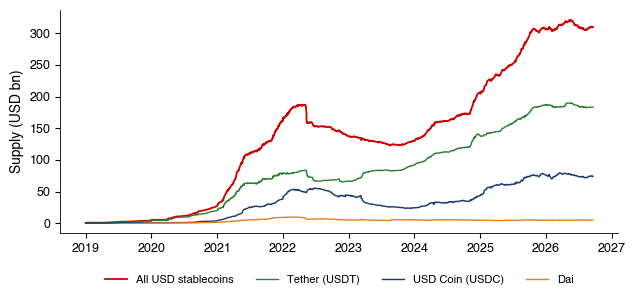

{'total_end': np.float64(309.519353146),
 'total_2020': np.float64(4.171183915),
 'usdt_end': np.float64(183.32932036),
 'usdc_end': np.float64(73.916109054),
 'dai_end': np.float64(4.771140262),
 'usdt_share': np.float64(59.23032550198039),
 'usdc_share': np.float64(23.880932905392136),
 'usdc_peak': 79.62020699,
 'usdc_peak_date': '2026-03-18',
 'n_coins': 339,
 'mech': {'algorithmic': 0.6648407611821288,
  'crypto-backed': 26.33730491177683,
  'fiat-backed': 285.68932469836193},
 'end': '2026-09-18',
 'tot_peak22': 187.391942652,
 'tot_peak22_date': '2022-04-02',
 'tot_trough': 122.660540921,
 'tot_trough_date': '2023-08-19',
 'usdc_peak22': 55.19135477,
 'usdc_peak22_date': '2022-06-20',
 'usdc_trough': 23.171550057,
 'usdc_trough_date': '2023-11-15'}

In [10]:
def fig_stablecoin_supply():
    """Oferta stablecoin-urilor ancorate la USD: total, USDT, USDC, DAI (miliarde USD)."""
    tot = stablecoin_chart()['value'].loc['2019-01-01':]
    parts = {'USDT': stablecoin_chart(1)['value'], 'USDC': stablecoin_chart(2)['value'], 'DAI': stablecoin_chart(5)['value']}
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    ax.plot(tot.index, tot.values, color=IDAred, lw=1.3, label='All USD stablecoins')
    for k, s in parts.items():
        s = s.loc['2019-01-01':]
        ax.plot(s.index, s.values, color=COL[k], lw=1.0, label=LABELS[k])
    ax.set_ylabel('Supply (USD bn)')
    legend_outside_bottom(ax, ncol=4, y=-0.14)
    save_fig('ch16_stablecoin_supply')
    lst = stablecoin_list()
    mech = lst.assign(mechanism=lst['mechanism'].replace({'crytpo-backed': 'crypto-backed'})).groupby('mechanism')['supply'].sum()
    return dict(total_end=tot.iloc[-1], total_2020=tot.loc[:'2020-01-01'].iloc[-1],
                usdt_end=parts['USDT'].iloc[-1], usdc_end=parts['USDC'].iloc[-1], dai_end=parts['DAI'].iloc[-1],
                usdt_share=100 * parts['USDT'].iloc[-1] / tot.iloc[-1], usdc_share=100 * parts['USDC'].iloc[-1] / tot.iloc[-1],
                usdc_peak=parts['USDC'].max(), usdc_peak_date=str(parts['USDC'].idxmax().date()),
                n_coins=int(len(lst)), mech={k: float(v) for k, v in mech.items()},
                top=[dict(symbol=r.symbol, name=r.name, mechanism=r.mechanism, supply=r.supply) for r in lst.head(12).itertuples()],
                end=str(tot.index[-1].date()),
                tot_peak22=tot.loc[:'2022-12-31'].max(), tot_peak22_date=str(tot.loc[:'2022-12-31'].idxmax().date()),
                tot_trough=tot.loc['2022-06-01':'2024-06-30'].min(),
                tot_trough_date=str(tot.loc['2022-06-01':'2024-06-30'].idxmin().date()),
                usdc_peak22=parts['USDC'].loc[:'2022-12-31'].max(),
                usdc_peak22_date=str(parts['USDC'].loc[:'2022-12-31'].idxmax().date()),
                usdc_trough=parts['USDC'].loc['2022-06-01':'2024-06-30'].min(),
                usdc_trough_date=str(parts['USDC'].loc['2022-06-01':'2024-06-30'].idxmin().date()))


ss = fig_stablecoin_supply()
{k: v for k, v in ss.items() if k != 'top'}

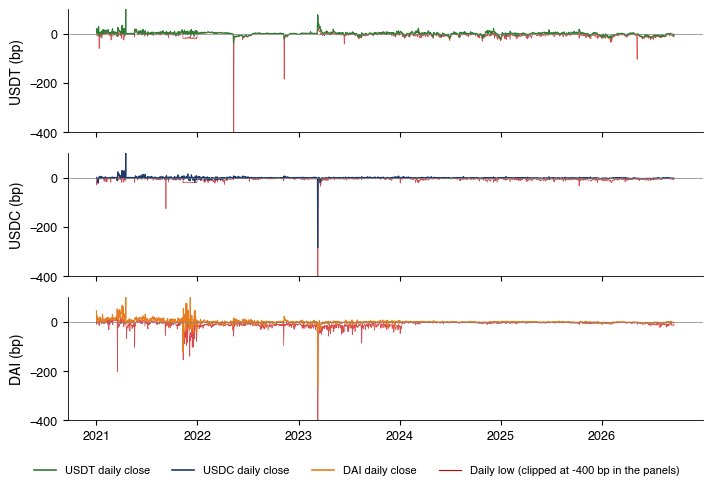

,USDT,USDC,DAI
N,2087,2087,2087
sd,7.287367,7.482593,10.83264
mad,3.081398,1.126255,2.212519
gt50,0.143747,0.143747,0.574988
gt100,0.047916,0.095831,0.143747
low_min,-515.138921,-1226.0,-1029.967719
low_min_date,2022-05-12,2023-03-11,2023-03-11
high_max,330.189504,13495.563783,26683.978839
high_max_date,2021-11-16,2021-11-16,2021-11-16
close_min,-41.278609,-285.0,-261.31348


In [11]:
def peg_stats(key, start='2021-01-01'):
    """Abaterea de la paritate (puncte de baza) pe preturile de inchidere si pe minimele zilnice."""
    d = read_market(ASSETS[key][0]).loc[start:END]
    dev = 1e4 * (d['close'] - 1)
    low = 1e4 * (d['low'] - 1)
    high = 1e4 * (d['high'] - 1)
    x = dev.values
    phi = np.corrcoef(x[1:], x[:-1])[0, 1]
    return dict(N=len(dev), sd=dev.std(), mad=np.median(np.abs(dev)), gt50=100 * (dev.abs() > 50).mean(),
                gt100=100 * (dev.abs() > 100).mean(), low_min=low.min(), low_min_date=str(low.idxmin().date()),
                high_max=high.max(), high_max_date=str(high.idxmax().date()), close_min=dev.min(),
                close_min_date=str(dev.idxmin().date()), phi=phi, half_life=np.log(0.5) / np.log(abs(phi)))


def fig_peg_deviation(start='2021-01-01'):
    """Abaterea zilnica de la 1 USD pentru USDT, USDC si DAI (inchidere si minimul zilei)."""
    fig, axes = plt.subplots(3, 1, figsize=(7.2, 4.6), sharex=True)
    out = {}
    for ax, k in zip(axes, STABLE):
        d = read_market(ASSETS[k][0]).loc[start:END]
        dev = 1e4 * (d['close'] - 1)
        low = 1e4 * (d['low'] - 1)
        ax.plot(low.index, low.clip(lower=-1500).values, color=IDAred, lw=0.5, alpha=0.7, label='Daily low')
        ax.plot(dev.index, dev.values, color=COL[k], lw=0.8, label=f'Daily close')
        ax.axhline(0, color=Gray, lw=0.5)
        ax.set_ylim(-400, 100)
        ax.set_ylabel(f'{k} (bp)')
        out[k] = peg_stats(k, start)
    h = [plt.Line2D([], [], color=COL[k], lw=1.2) for k in STABLE] + [plt.Line2D([], [], color=IDAred, lw=0.8)]
    fig.tight_layout()
    fig_legend_bottom(fig, h, ['USDT daily close', 'USDC daily close', 'DAI daily close',
                               'Daily low (clipped at -400 bp in the panels)'], ncol=4, y=0.0)
    save_fig('ch16_peg_deviation')
    return out


pd.DataFrame(fig_peg_deviation()).round(2)

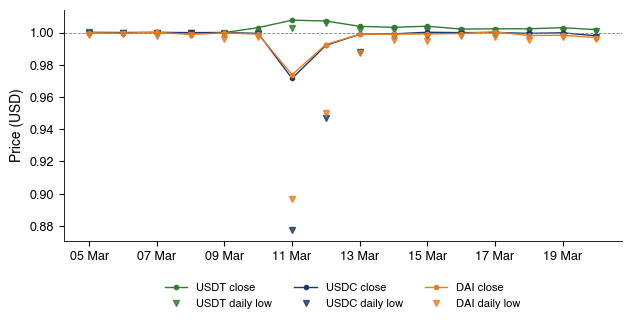

{'USDT': {'low': 0.9998157786, 'low_date': '2023-03-09', 'close_min': 0.9999858088, 'high': 1.0296284355, 'close_max': 1.00769}, 'USDC': {'low': 0.8774, 'low_date': '2023-03-11', 'close_min': 0.9715, 'high': 1.0009154368, 'close_max': 1.0001843997}, 'DAI': {'low': 0.8970032281, 'low_date': '2023-03-11', 'close_min': 0.973868652, 'high': 1.0025748001, 'close_max': 1.0004739766}}


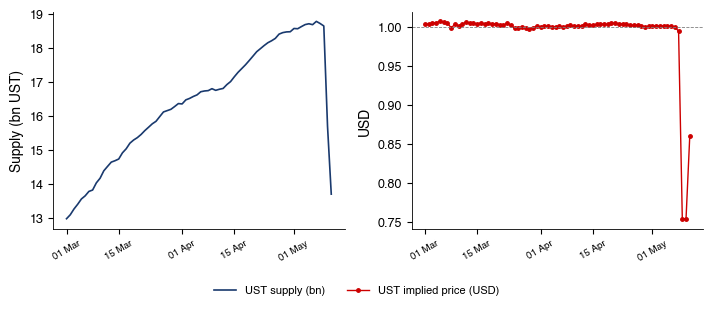

{'supply_peak': 18.770471902,
 'supply_peak_date': '2022-05-07',
 'supply_last': np.float64(13.692512964),
 'last_date': '2022-05-11',
 'px_min': 0.7539999999539609,
 'px_min_date': '2022-05-10',
 'drop_pct': np.float64(27.05291036108124)}

In [12]:
def fig_depeg_2023():
    """Martie 2023: USDC si DAI sub paritate dupa inchiderea Silicon Valley Bank; USDT peste paritate."""
    a, b = '2023-03-05', '2023-03-20'
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    out = {}
    for k in STABLE:
        d = read_market(ASSETS[k][0]).loc[a:b]
        ax.plot(d.index, d['close'], 'o-', color=COL[k], ms=3, lw=1.0, label=f'{k} close')
        ax.plot(d.index, d['low'], 'v', color=COL[k], ms=4, alpha=0.8, label=f'{k} daily low')
        out[k] = dict(low=d['low'].min(), low_date=str(d['low'].idxmin().date()), close_min=d['close'].min(),
                      high=d['high'].max(), close_max=d['close'].max())
    ax.axhline(1, color=Gray, lw=0.6, ls='--')
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    legend_outside_bottom(ax, ncol=3, y=-0.14)
    save_fig('ch16_depeg_2023')
    return out


def fig_ust():
    """TerraUSD (UST), aprilie-mai 2022: oferta si pretul implicit (valoare / oferta), DefiLlama."""
    u = stablecoin_chart(3).loc['2022-03-01':'2022-05-31'].copy()
    u = u[u['supply'] > 0]
    u['px'] = u['value'] / u['supply']
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
    axes[0].plot(u.index, u['supply'], color=MainBlue, lw=1.2, label='UST supply (bn)')
    axes[0].set_ylabel('Supply (bn UST)')
    axes[1].plot(u.index, u['px'], 'o-', color=IDAred, ms=2.5, lw=1.0, label='UST implied price (USD)')
    axes[1].axhline(1, color=Gray, lw=0.6, ls='--')
    axes[1].set_ylabel('USD')
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
        ax.tick_params(axis='x', labelsize=7, rotation=30)
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch16_ust_collapse')
    last = u.index[-1]
    return dict(supply_peak=u['supply'].max(), supply_peak_date=str(u['supply'].idxmax().date()),
                supply_last=u['supply'].iloc[-1], last_date=str(last.date()), px_min=u['px'].min(),
                px_min_date=str(u['px'].idxmin().date()),
                drop_pct=100 * (1 - u['supply'].iloc[-1] / u['supply'].max()))


print(fig_depeg_2023())
fig_ust()

## 6. DeFi și formatorii automați de piață

- Schimb: $\Delta y = y\gamma\Delta x/(x + \gamma\Delta x)$; pierderea impermanentă $2\sqrt{r}/(1 + r) - 1$; pierderea față de reechilibrare $\sigma^2/8$.

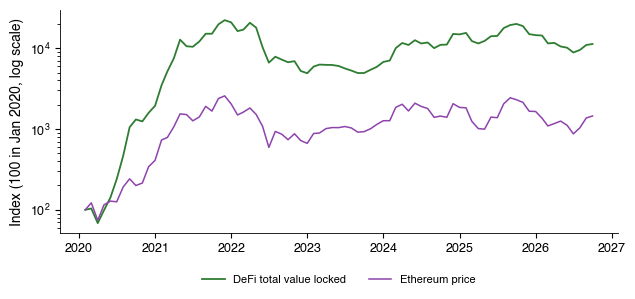

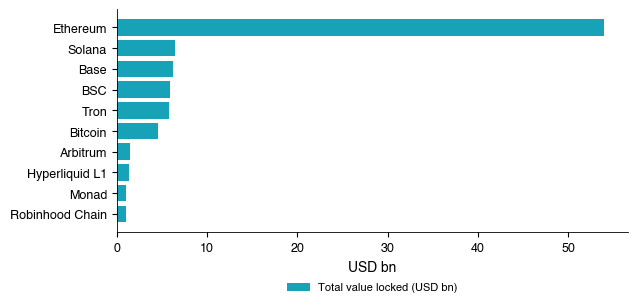

{'peak': 177.493346508,
 'peak_date': '2021-11-09',
 'last': np.float64(88.124131285),
 'last_date': '2026-09-18',
 'start': np.float64(0.606094144),
 'beta': np.float64(0.789487242953579),
 'se': np.float64(0.0657490592853692),
 'r2': np.float64(0.6203944833763284),
 'n': 80,
 'corr': np.float64(0.7876512447627618),
 'chains': {'Ethereum': 53.97008549962804,
  'Solana': 6.426447011806411,
  'Base': 6.1854372267444155,
  'BSC': 5.850511660115428,
  'Tron': 5.73701425826317,
  'Bitcoin': 4.546029924808896,
  'Arbitrum': 1.4699818721966753,
  'Hyperliquid L1': 1.3055266903330212,
  'Monad': 1.0232231185965848,
  'Robinhood Chain': 0.9979433131392076},
 'eth_share': np.float64(56.402887973120414),
 'chains_total': np.float64(95.68674129833252)}

In [13]:
def fig_defi_tvl():
    """TVL total (DefiLlama) si pretul Ethereum, lunar, 2020-2026; TVL pe blockchain-uri azi."""
    tvl = defi_tvl().loc['2020-01-01':]
    eth = price('ETH', '2020-01-01')
    m = pd.concat([tvl.resample('ME').last(), eth.resample('ME').last()], axis=1).dropna()
    m.columns = ['TVL', 'ETH']
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    ax.plot(m.index, 100 * m['TVL'] / m['TVL'].iloc[0], color=Forest, lw=1.3, label='DeFi total value locked')
    ax.plot(m.index, 100 * m['ETH'] / m['ETH'].iloc[0], color=Purple, lw=1.1, label='Ethereum price')
    ax.set_yscale('log')
    ax.set_ylabel('Index (100 in Jan 2020, log scale)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_defi_tvl')
    d = np.log(m).diff().dropna()
    reg = hac_ols(d['TVL'], d['ETH'], lags=3)
    ch = chain_tvl().head(10)
    fig, ax = plt.subplots(figsize=(6.6, 2.9))
    ax.barh(ch.index[::-1], ch.values[::-1], color=Teal, label='Total value locked (USD bn)')
    ax.set_xlabel('USD bn')
    legend_outside_bottom(ax, ncol=1, y=-0.18)
    save_fig('ch16_tvl_chains')
    tot_now = chain_tvl().sum()
    return dict(peak=tvl.max(), peak_date=str(tvl.idxmax().date()), last=tvl.iloc[-1], last_date=str(tvl.index[-1].date()),
                start=tvl.iloc[0], beta=reg.params['ETH'], se=reg.bse['ETH'], r2=reg.rsquared, n=len(d),
                corr=d['TVL'].corr(d['ETH']), chains={k: float(v) for k, v in ch.items()},
                eth_share=100 * ch.iloc[0] / tot_now, chains_total=tot_now)


fig_defi_tvl()

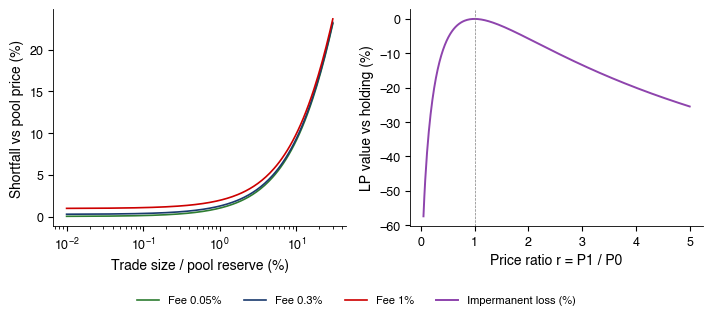

{'fee0.0005': {'0.001': 0.14980027462551115, '0.01': 1.0391140550200628, '0.05': 4.807257315650382, '0.1': 9.13223328333106}, 'fee0.003': {'0.001': 0.3993018960096739, '0.01': 1.284196560293871, '0.05': 5.034052483688145, '0.1': 9.338910611985074}, 'fee0.01': {'0.001': 1.0979130660646041, '0.01': 1.9704921279334653, '0.05': 5.669366364935691, '0.1': 9.91810737033667}, 'il': {'0.25': -19.999999999999996, '0.5': -5.719095841793653, '0.8': -0.6192010000093506, '1.25': -0.6192010000093395, '2': -5.719095841793653, '4': -19.999999999999996}}


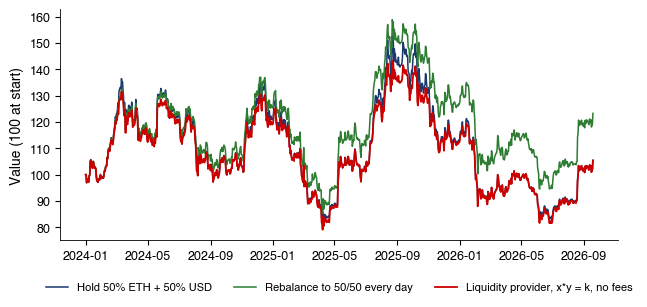

{'start': '2024-01-01',
 'p0': np.float64(2352.327940665),
 'p1': np.float64(2611.3471679688),
 'ratio': np.float64(1.110111869534048),
 'hodl': np.float64(105.50559347670242),
 'lp': np.float64(105.3618464879032),
 'reb': np.float64(123.27143266781309),
 'il': np.float64(-0.13624584636924286),
 'sigma': np.float64(68.05867468075657),
 'lvr_theory': 5.78997899912632,
 'lvr_real': np.float64(5.786065338541193),
 'years': 2.7132101300479126,
 'fee_apr_hodl': np.float64(0.050249976550993995)}

In [14]:
def amm_swap(x, y, dx, fee=0.003):
    """Schimb dx din activul X intr-un fond x*y = k cu comision fee: cantitatea primita si pretul efectiv."""
    g = 1 - fee
    dy = y * g * dx / (x + g * dx)
    return dy, dy / dx


def impermanent_loss(r):
    """Pierderea impermanenta a unui furnizor de lichiditate 50/50 x*y = k, pentru raportul de pret r = P1/P0."""
    return 2 * np.sqrt(r) / (1 + r) - 1


def fig_amm_theory():
    """Alunecarea pretului in functie de marimea ordinului si pierderea impermanenta."""
    delta = np.logspace(-4, np.log10(0.3), 200)
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9))
    out = {}
    for fee, c in [(0.0005, Forest), (0.003, MainBlue), (0.01, IDAred)]:
        g = 1 - fee
        slip = 100 * (1 - g / (1 + g * delta))
        axes[0].plot(100 * delta, slip, color=c, lw=1.2, label=f'Fee {100 * fee:g}%')
        out[f'fee{fee}'] = {f'{d:g}': float(100 * (1 - g / (1 + g * d))) for d in [0.001, 0.01, 0.05, 0.1]}
    axes[0].set_xscale('log')
    axes[0].set_xlabel('Trade size / pool reserve (%)')
    axes[0].set_ylabel('Shortfall vs pool price (%)')
    rr = np.linspace(0.05, 5, 300)
    axes[1].plot(rr, 100 * impermanent_loss(rr), color=Purple, lw=1.4, label='Impermanent loss (%)')
    axes[1].axvline(1, color=Gray, lw=0.5, ls='--')
    axes[1].set_xlabel('Price ratio r = P1 / P0')
    axes[1].set_ylabel('LP value vs holding (%)')
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=4, y=0.0)
    save_fig('ch16_amm_theory')
    out['il'] = {f'{r:g}': float(100 * impermanent_loss(r)) for r in [0.25, 0.5, 0.8, 1.25, 2, 4]}
    return out


def fig_lp_vs_hodl(start='2024-01-01'):
    """Fond ETH/USD x*y = k fara comisioane: furnizorul de lichiditate vs pastrarea activelor vs reechilibrarea zilnica 50/50."""
    p = price('ETH', start)
    rel = p / p.iloc[0]
    hodl = 100 * (1 + rel) / 2
    lp = 100 * np.sqrt(rel)
    R = p.pct_change().fillna(0)
    reb = 100 * (1 + 0.5 * R).cumprod()
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    ax.plot(hodl.index, hodl.values, color=MainBlue, lw=1.1, label='Hold 50% ETH + 50% USD')
    ax.plot(reb.index, reb.values, color=Forest, lw=1.1, label='Rebalance to 50/50 every day')
    ax.plot(lp.index, lp.values, color=IDAred, lw=1.3, label='Liquidity provider, x*y = k, no fees')
    ax.set_ylabel('Value (100 at start)')
    legend_outside_bottom(ax, ncol=3, y=-0.14)
    save_fig('ch16_lp_vs_hodl')
    r = np.log(p).diff().dropna()
    sig2 = r.var() * 365
    yrs = (p.index[-1] - p.index[0]).days / 365.25
    lvr_real = np.log(reb.iloc[-1] / lp.iloc[-1]) / yrs
    return dict(start=str(p.index[0].date()), p0=p.iloc[0], p1=p.iloc[-1], ratio=rel.iloc[-1], hodl=hodl.iloc[-1],
                lp=lp.iloc[-1], reb=reb.iloc[-1], il=100 * (lp.iloc[-1] / hodl.iloc[-1] - 1), sigma=100 * np.sqrt(sig2),
                lvr_theory=100 * sig2 / 8, lvr_real=100 * lvr_real, years=yrs,
                fee_apr_hodl=100 * np.log(hodl.iloc[-1] / lp.iloc[-1]) / yrs)


print(fig_amm_theory())
fig_lp_vs_hodl()

## 7. ETF-uri spot și acțiuni „cripto”

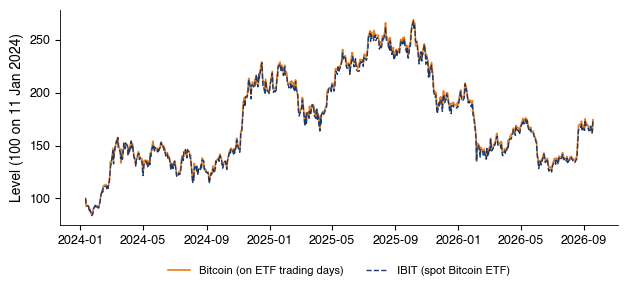

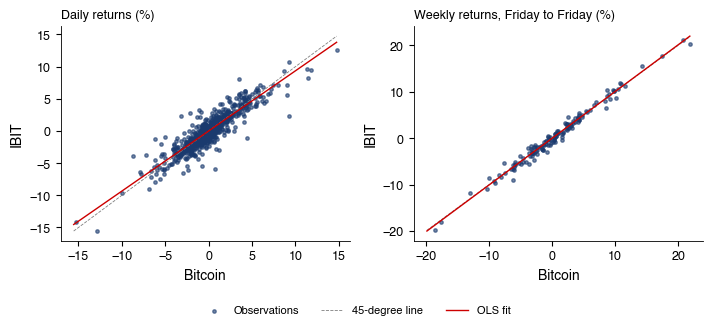

,ibit,etha
start,2024-01-11,2024-07-23
n_d,673,541
n_w,140,112
beta_d,0.934804,0.938312
r2_d,0.824884,0.826042
beta_d_next,0.036581,0.012422
beta_d_same,0.936389,0.937121
r2_d_two,0.824847,0.825407
beta_w,1.007122,0.985703
se_w,0.011341,0.017147


In [15]:
def etf_tracking(etf='IBIT', coin='BTC'):
    """Randamente ETF vs activ suport in zilele de tranzactionare ale ETF-ului: zilnic (aceeasi data si data urmatoare)
    si saptamanal (vineri); abaterea de urmarire; deriva raportului ETF / activ (comisionul anual)."""
    p = joint_prices([etf, coin])
    r = np.log(p).diff().dropna()
    c_next = np.log(price(coin)).diff().shift(-1).reindex(r.index)
    d_same = hac_ols(r[etf], r[coin])
    xx = pd.concat([r[coin], c_next.rename('next')], axis=1).dropna()
    d_two = hac_ols(r[etf].reindex(xx.index), xx)
    w = joint_returns([etf, coin], freq='W')
    wk = hac_ols(w[etf], w[coin])
    te_d = 100 * (r[etf] - r[coin]).std() * np.sqrt(252)
    te_w = 100 * (w[etf] - w[coin]).std() * np.sqrt(52)
    lr = np.log(p[etf] / p[coin])
    t = (lr.index - lr.index[0]).days / 365.25
    drift = np.polyfit(t, lr.values, 1)[0]
    vol = read_market(ASSETS[etf][0])
    dv = (vol['close'] * vol['volume']).loc[:END] / 1e9
    return dict(start=str(p.index[0].date()), n_d=len(r), n_w=len(w), beta_d=d_same.params[coin], r2_d=d_same.rsquared,
                beta_d_next=d_two.params['next'], beta_d_same=d_two.params[coin], r2_d_two=d_two.rsquared,
                beta_w=wk.params[coin], se_w=wk.bse[coin], r2_w=wk.rsquared, te_d=te_d, te_w=te_w,
                drift=100 * drift, corr_next=r[etf].corr(c_next), dv_mean=dv.mean(), dv_last60=dv.iloc[-60:].mean(),
                dv_max=dv.max(), dv_max_date=str(dv.idxmax().date()))


def fig_etf():
    """IBIT si Bitcoin: nivelurile normalizate si randamentele zilnice vs saptamanale."""
    p = joint_prices(['IBIT', 'BTC'])
    n = 100 * p / p.iloc[0]
    fig, ax = plt.subplots(figsize=(7.2, 2.8))
    ax.plot(n.index, n['BTC'], color=Orange, lw=1.2, label='Bitcoin (on ETF trading days)')
    ax.plot(n.index, n['IBIT'], color=MainBlue, lw=1.0, ls='--', label='IBIT (spot Bitcoin ETF)')
    ax.set_ylabel('Level (100 on 11 Jan 2024)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_etf_tracking')
    r = np.log(p).diff().dropna() * 100
    w = joint_returns(['IBIT', 'BTC'], freq='W') * 100
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))
    for ax, x, lab in [(axes[0], r, 'Daily returns (%)'), (axes[1], w, 'Weekly returns, Friday to Friday (%)')]:
        ax.scatter(x['BTC'], x['IBIT'], s=6, color=MainBlue, alpha=0.6, label='Observations')
        lim = [min(x.min()), max(x.max())]
        ax.plot(lim, lim, color=Gray, lw=0.6, ls='--', label='45-degree line')
        b = np.polyfit(x['BTC'], x['IBIT'], 1)
        ax.plot(lim, np.polyval(b, lim), color=IDAred, lw=1.0, label='OLS fit')
        ax.set_xlabel('Bitcoin')
        ax.set_ylabel('IBIT')
        ax.set_title(lab, fontsize=9, loc='left')
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=3, y=0.0)
    save_fig('ch16_etf_timing')
    return dict(ibit=etf_tracking('IBIT', 'BTC'), etha=etf_tracking('ETHA', 'ETH'),
                ibit_end=n['IBIT'].iloc[-1], btc_end=n['BTC'].iloc[-1])


etf = fig_etf()
pd.DataFrame({k: etf[k] for k in ['ibit', 'etha']}).round(3)

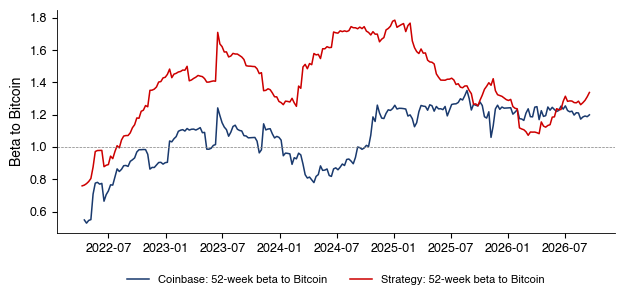

{'COIN': {'n': 283,
  'a': np.float64(-37.1076394972931),
  'b_btc': np.float64(0.7910266844934069),
  'se_btc': np.float64(0.08866809352388204),
  'b_spx': np.float64(2.052364275536415),
  'se_spx': np.float64(0.22120064234878067),
  'r2': np.float64(0.5150423663570067),
  'b1': np.float64(0.9471280007414183),
  'r2_1': np.float64(0.3773906614310575),
  'vol': np.float64(84.2438897657084),
  'beta_last': np.float64(1.1991328215119865),
  'beta_min': 0.5284704945617862,
  'beta_max': 1.350240314556642,
  'corr': np.float64(0.6143213014628897)},
 'MSTR': {'n': 284,
  'a': np.float64(-4.513010727188793),
  'b_btc': np.float64(1.1790462926504703),
  'se_btc': np.float64(0.10906314033889425),
  'b_spx': np.float64(1.0237323842127528),
  'se_spx': np.float64(0.24077911294751544),
  'r2': np.float64(0.6296820667195857),
  'b1': np.float64(1.2571629283519503),
  'r2_1': np.float64(0.5988774326110564),
  'vol': np.float64(88.69052432912956),
  'beta_last': np.float64(1.3376273702589119),
  'be

In [16]:
def fig_crypto_equities(start='2021-04-16'):
    """Regresii saptamanale cu doi factori (Bitcoin, S&P 500) si beta mobil pe 52 de saptamani fata de Bitcoin."""
    out = {}
    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    for k in ['COIN', 'MSTR']:
        w = joint_returns([k, 'BTC', 'SPX'], start, freq='W')
        m = hac_ols(w[k], w[['BTC', 'SPX']])
        m1 = hac_ols(w[k], w['BTC'])
        cov = w[k].rolling(52).cov(w['BTC'])
        beta = (cov / w['BTC'].rolling(52).var()).dropna()
        ax.plot(beta.index, beta.values, color=COL[k], lw=1.1, label=f'{LABELS[k]}: 52-week beta to Bitcoin')
        out[k] = dict(n=len(w), a=52 * 100 * m.params['const'], b_btc=m.params['BTC'], se_btc=m.bse['BTC'],
                      b_spx=m.params['SPX'], se_spx=m.bse['SPX'], r2=m.rsquared, b1=m1.params['BTC'], r2_1=m1.rsquared,
                      vol=100 * w[k].std() * np.sqrt(52), beta_last=beta.iloc[-1], beta_min=beta.min(),
                      beta_max=beta.max(), corr=w[k].corr(w['BTC']))
    ax.axhline(1, color=Gray, lw=0.5, ls='--')
    ax.set_ylabel('Beta to Bitcoin')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch16_crypto_equities')
    wb = joint_returns(['BTC', 'SPX'], start, freq='W')
    out['btc_vol'] = 100 * wb['BTC'].std() * np.sqrt(52)
    return out


fig_crypto_equities()

## 8. Devin cripto-activele active alternative?

- Caracteristici de coadă, memorie și momente pentru 26 de active, în două ferestre; componente principale; distanțe între centrele claselor.

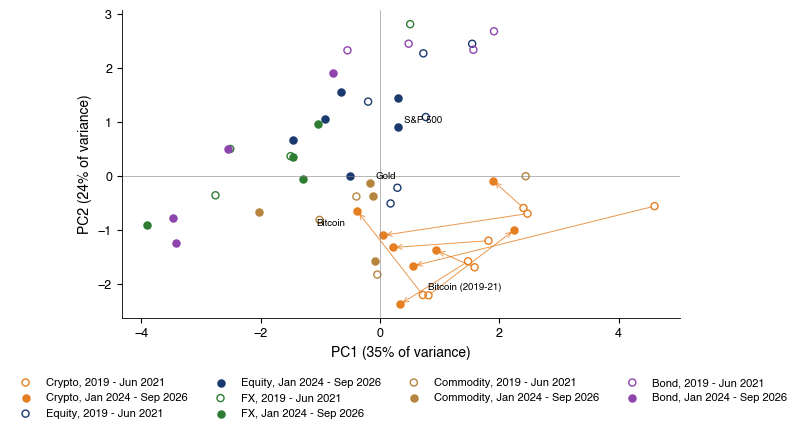

{'ev1': np.float64(34.890637857384085),
 'ev2': np.float64(24.356269632257067),
 'loadings': {'ann_vol': -0.43599343849678973,
  'skew': -0.13570351556372814,
  'kurt': -0.5164730253622505,
  'acf1': 0.046835224117058545,
  'acf1_sq': -0.07944382469180297,
  'hill_left': 0.47672939246587587,
  'hill_right': 0.33800261142376964,
  'mdd': 0.4180052069707118},
 'W1': {'dist_equity': 3.026268739604914,
  'dist_commodity': 2.2620342454943065,
  'dist_fx': 4.2476990154113885,
  'dist_bond': 4.326436872324231,
  'spread_crypto': 2.127894792768567,
  'btc_vol': 76.9421239103302,
  'crypto_kurt': 16.927262706295515},
 'W2': {'dist_equity': 2.632580686516067,
  'dist_commodity': 1.8568852270601266,
  'dist_fx': 3.3573944504644215,
  'dist_bond': 3.7064469734826155,
  'spread_crypto': 1.426165841980473,
  'btc_vol': 47.429186944092486,
  'crypto_kurt': 4.019071649713214}}

In [17]:
WINDOWS = {'W1': ('2019-01-01', '2021-06-30'), 'W2': ('2024-01-11', '2026-09-18')}
FEATURES = ['ann_vol', 'skew', 'kurt', 'acf1', 'acf1_sq', 'hill_left', 'hill_right', 'mdd']


def asset_features(r):
    """Caracteristicile statistice ale unei serii de randamente log zilnice."""
    ppy = periods_per_year(r)
    p = np.exp(r.cumsum())
    return dict(ann_vol=np.log(r.std() * np.sqrt(ppy)), skew=stats.skew(r), kurt=np.log1p(max(stats.kurtosis(r), 0)),
                acf1=r.autocorr(1), acf1_sq=(r ** 2).autocorr(1), hill_left=hill(-r.values - (-r).median()),
                hill_right=hill(r.values - r.median()), mdd=(p / p.cummax() - 1).min())


def feature_table():
    """Tabelul caracteristicilor pe active si ferestre (W1: 2019 - iunie 2021; W2: era ETF-urilor spot)."""
    rows = []
    for s, (lab, cls, _) in CLASS_ASSETS.items():
        for w, (a, b) in WINDOWS.items():
            r = symbol_returns(s, a, b)
            rows.append(dict(symbol=s, label=lab, cls=cls, window=w, **asset_features(r)))
    return pd.DataFrame(rows)


def fig_alt_assets():
    """Componente principale ale caracteristicilor standardizate; distanta cripto - clasele traditionale."""
    f = feature_table()
    X = f[FEATURES].values
    Z = (X - X.mean(0)) / X.std(0)
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    pc = Z @ Vt[:2].T
    if np.corrcoef(pc[:, 0], f['ann_vol'])[0, 1] < 0:
        pc[:, 0] *= -1
    f['pc1'], f['pc2'] = pc[:, 0], pc[:, 1]
    ev = S ** 2 / (S ** 2).sum()
    fig, ax = plt.subplots(figsize=(7.2, 4.0))
    for cls, c in CLASS_COL.items():
        for w, mk, fc in [('W1', 'o', 'none'), ('W2', 'o', c)]:
            x = f[(f.cls == cls) & (f.window == w)]
            ax.scatter(x['pc1'], x['pc2'], s=26, marker=mk, facecolors=fc, edgecolors=c, lw=1.0,
                       label=f'{cls}, ' + ('2019 - Jun 2021' if w == 'W1' else 'Jan 2024 - Sep 2026'))
    for s in f[f.cls == 'Crypto'].symbol.unique():
        a = f[(f.symbol == s) & (f.window == 'W1')].iloc[0]
        b = f[(f.symbol == s) & (f.window == 'W2')].iloc[0]
        ax.annotate('', xy=(b.pc1, b.pc2), xytext=(a.pc1, a.pc2),
                    arrowprops=dict(arrowstyle='->', color=Orange, lw=0.7, alpha=0.8))
    for s, w, dx, dy in [('BTC-USD.CC', 'W1', 4, 4), ('BTC-USD.CC', 'W2', -30, -10), ('GSPC.INDX', 'W2', 4, 3),
                         ('XAUUSD.FOREX', 'W2', 4, 3)]:
        b = f[(f.symbol == s) & (f.window == w)].iloc[0]
        lab = b.label + (' (2019-21)' if w == 'W1' else '')
        ax.annotate(lab, (b.pc1, b.pc2), xytext=(dx, dy), textcoords='offset points', fontsize=7, color='black')
    ax.axhline(0, color=Gray, lw=0.4)
    ax.axvline(0, color=Gray, lw=0.4)
    ax.set_xlabel(f'PC1 ({100 * ev[0]:.0f}% of variance)')
    ax.set_ylabel(f'PC2 ({100 * ev[1]:.0f}% of variance)')
    legend_outside_bottom(ax, ncol=4, y=-0.16)
    save_fig('ch16_alt_assets')
    # distante in spatiul complet standardizat
    f[[f'z_{c}' for c in FEATURES]] = Z
    zc = [f'z_{c}' for c in FEATURES]
    out = dict(ev1=100 * ev[0], ev2=100 * ev[1], loadings={c: float(v) for c, v in zip(FEATURES, Vt[0])})
    for w in WINDOWS:
        g = f[f.window == w]
        cen = g.groupby('cls')[zc].mean()
        cr = g[g.cls == 'Crypto'][zc].values
        out[w] = dict(dist_equity=float(np.linalg.norm(cen.loc['Crypto'] - cen.loc['Equity'])),
                      dist_commodity=float(np.linalg.norm(cen.loc['Crypto'] - cen.loc['Commodity'])),
                      dist_fx=float(np.linalg.norm(cen.loc['Crypto'] - cen.loc['FX'])),
                      dist_bond=float(np.linalg.norm(cen.loc['Crypto'] - cen.loc['Bond'])),
                      spread_crypto=float(np.mean(np.linalg.norm(cr - cr.mean(0), axis=1))),
                      btc_vol=float(np.exp(g[g.symbol == 'BTC-USD.CC']['ann_vol'].iloc[0]) * 100),
                      crypto_kurt=float(np.expm1(g[g.cls == 'Crypto']['kurt']).median()))
    f.drop(columns=zc).to_csv(os.path.join(HERE, 'ch16_asset_features.csv'), index=False)
    return out


fig_alt_assets()